### `SLCE3` Buscando entender a influencia das predições em intervalos futuros

#### Apresentação e tratamento
Vamos cobrir o periodo de `2018-01-02` a `2024-12-30`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


# Carrega o dataset
df = pd.read_csv('SLCE3.csv')

# Exibe as primeiras 5 linhas do DataFrame
print("Primeiras 5 linhas do DataFrame:")
print(df.head())

# Exibe informações gerais sobre o DataFrame
print("\nInformações gerais do DataFrame:")
print(df.info())


# Verifica se há valores negativos nas colunas 'Close' e 'Open'
print("\nVerificando valores negativos nas colunas 'Close' e 'Open':")
negative_close = df[df['Close'] < 0]
negative_open = df[df['Open'] < 0]
negative_high = df[df['High'] < 0]
negative_low = df[df['Low'] < 0]
negative_volum = df[df['Volume'] < 0]

if negative_close.empty:
    print("\nNão há valores negativos na coluna 'Close'.")

if negative_open.empty:
    print("Não há valores negativos na coluna 'Open'.")

if negative_high.empty:
    print("Não há valores negativos na coluna 'High'.")

if negative_low.empty:
    print("Não há valores negativos na coluna 'Low'.")

if negative_volum.empty:
    print("Não há valores negativos na coluna 'Volume'.")


Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open   Volume
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738 entries, 0 to 1737
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1738 non-null   object 
 1   Close   1738 non-null   float64
 2   High    1738 non-null   float64
 3   Low     1738 non-null   float64
 4   Open    1738 non-null   float64
 5   Volume  1738 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 81.6+ KB
None

Verificando valores negativos nas colunas 'Close' e 'Open':

Não há valores negativo

### Adicionando colunas de valores futuros

In [2]:
df['Close_Open_Diff'] = df['Close'] - df['Open']

print("Primeiras 5 linhas do DataFrame com a nova coluna 'Close_Open_Diff':")
print(df.head())

sns.set_style("whitegrid")

# columns_to_plot = ['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Open_Diff']
# plt.figure(figsize=(15, 10))
# for i, col in enumerate(columns_to_plot):
#     plt.subplot(2, 3, i + 1) # 2 linhas, 3 colunas de gráficos
#     sns.histplot(df[col], kde=True, bins=30) # type: ignore
#     plt.title(f'Distribuição de {col}')
#     plt.xlabel(col)
#     plt.ylabel('Frequência')

# plt.tight_layout()
# plt.savefig('distribuicao_dados_exploratorio.png')

# Exibir estatísticas descritivas atualizadas com a nova coluna
print("\nEstatísticas descritivas do DataFrame (com 'Close_Open_Diff'):")
print(df.describe())

# Adicionando colunas de fechamento futuro | dias uteis != dias corridos
df['Close_1d_fut'] = df['Close'].shift(-1)
df['Close_3d_fut'] = df['Close'].shift(-3)
df['Close_7d_fut'] = df['Close'].shift(-7)
df['Close_15d_fut'] = df['Close'].shift(-15)
df['Close_30d_fut'] = df['Close'].shift(-30)
df['Volume_1d_fut'] = df['Volume'].shift(-1)
df['Volume_3d_fut'] = df['Volume'].shift(-3)
df['Volume_7d_fut'] = df['Volume'].shift(-7)
df['Volume_15d_fut'] = df['Volume'].shift(-15)
df['Volume_30d_fut'] = df['Volume'].shift(-30)

print("\nPrimeiras linhas com colunas de fechamento futuro:")
print(df[['Close', 'Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut', 'Volume_1d_fut', 'Volume_3d_fut','Volume_7d_fut', 'Volume_15d_fut', 'Volume_30d_fut']].head(35))

# Remover linhas com qualquer valor futuro nulo
df_process = df.dropna(subset=['Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut', 'Volume_1d_fut', 'Volume_3d_fut','Volume_7d_fut', 'Volume_15d_fut', 'Volume_30d_fut']).copy()

# Salvar o dataset processado
df_process.to_csv('SLCE3_process.csv', index=False)
print("DataFrame processado salvo como 'SLCE3_process.csv'.")


Primeiras 5 linhas do DataFrame com a nova coluna 'Close_Open_Diff':
         Date     Close      High       Low      Open   Volume  \
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908   
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536   
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724   
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248   
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172   

   Close_Open_Diff  
0         0.105752  
1         0.026716  
2        -0.012245  
3         0.012245  
4        -0.016698  

Estatísticas descritivas do DataFrame (com 'Close_Open_Diff'):
             Close         High          Low         Open        Volume  \
count  1738.000000  1738.000000  1738.000000  1738.000000  1.738000e+03   
mean     12.853513    13.075743    12.651012    12.864267  3.029539e+06   
std       5.343477     5.411924     5.279755     5.346681  1.646280e+06   
min       3.077934     3.103537     2.972182

### Treinando modelo: Volume vs Close_1d_fut



Gráfico salvo como 'regressao_volume_close_1d_fut.png'

Métricas do Modelo (Volume vs Close_1d_fut):
Coeficiente: 0.00000034
Intercepto: 11.8559
R-quadrado: 0.0064


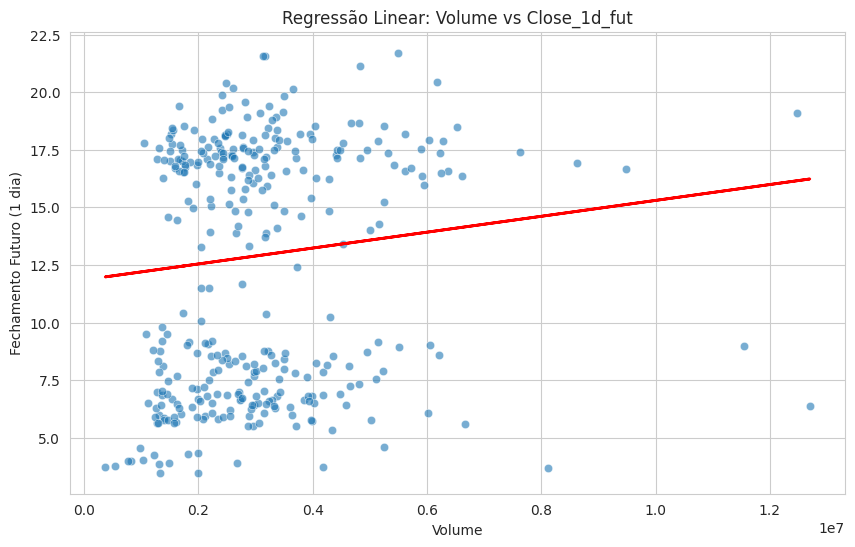

In [3]:
# Selecionar o atributo 'Volume' como variável independente e 'Close_1d_fut' como alvo
X_volume = df_process[['Volume']]
y_close_1d_fut = df_process['Close_1d_fut']

# Dividir os dados em treino e teste
X_train_vol_1d, X_test_vol_1d, y_train_1d, y_test_1d = train_test_split(X_volume, y_close_1d_fut, test_size=0.2, random_state=42)

model_vol_1d = LinearRegression()
model_vol_1d.fit(X_train_vol_1d, y_train_1d)
y_pred_vol_1d = model_vol_1d.predict(X_test_vol_1d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_vol_1d['Volume'], y=y_test_1d, alpha=0.6)
plt.plot(X_test_vol_1d['Volume'], y_pred_vol_1d, color='red', linewidth=2)
plt.title('Regressão Linear: Volume vs Close_1d_fut')
plt.xlabel('Volume')
plt.ylabel('Fechamento Futuro (1 dia)')
plt.grid(True)
plt.savefig('regressao_volume_close_1d_fut.png')
print("\nGráfico salvo como 'regressao_volume_close_1d_fut.png'")

print("\nMétricas do Modelo (Volume vs Close_1d_fut):")
print(f"Coeficiente: {model_vol_1d.coef_[0]:.8f}")
print(f"Intercepto: {model_vol_1d.intercept_:.4f}")
print(f"R-quadrado: {model_vol_1d.score(X_test_vol_1d, y_test_1d):.4f}")


### Treinando modelo: Volume vs Close_3d_fut



Gráfico salvo como 'regressao_volume_close_3d_fut.png'

Métricas do Modelo (Volume vs Close_3d_fut):
Coeficiente: 0.00000033
Intercepto: 11.9039
R-quadrado: 0.0066


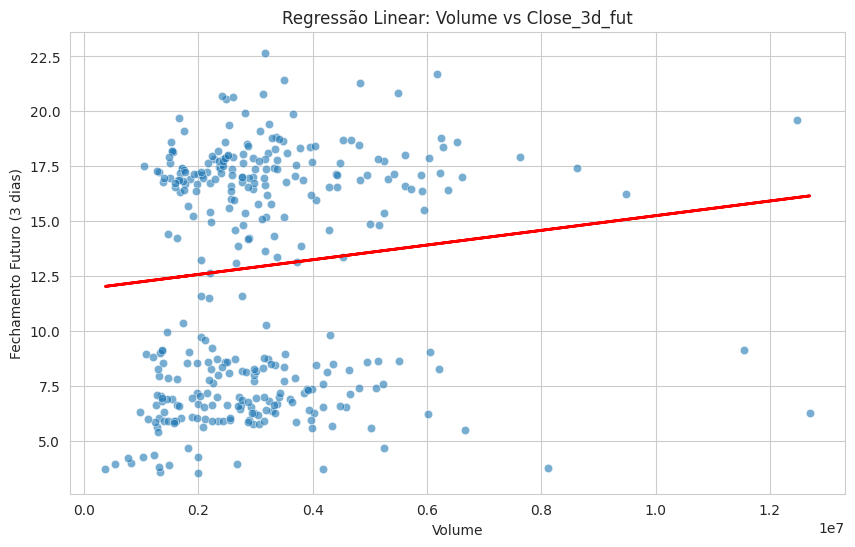

In [4]:
# Selecionar o atributo 'Volume' como variável independente e 'Close_3d_fut' como alvo
X_volume = df_process[['Volume']]
y_close_3d_fut = df_process['Close_3d_fut']

# Dividir os dados em treino e teste
X_train_vol_3d, X_test_vol_3d, y_train_3d, y_test_3d = train_test_split(X_volume, y_close_3d_fut, test_size=0.2, random_state=42)

model_vol_3d = LinearRegression()
model_vol_3d.fit(X_train_vol_3d, y_train_3d)
y_pred_vol_3d = model_vol_3d.predict(X_test_vol_3d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_vol_3d['Volume'], y=y_test_3d, alpha=0.6)
plt.plot(X_test_vol_3d['Volume'], y_pred_vol_3d, color='red', linewidth=2)
plt.title('Regressão Linear: Volume vs Close_3d_fut')
plt.xlabel('Volume')
plt.ylabel('Fechamento Futuro (3 dias)')
plt.grid(True)
plt.savefig('regressao_volume_close_3d_fut.png')
print("\nGráfico salvo como 'regressao_volume_close_3d_fut.png'")

print("\nMétricas do Modelo (Volume vs Close_3d_fut):")
print(f"Coeficiente: {model_vol_3d.coef_[0]:.8f}")
print(f"Intercepto: {model_vol_3d.intercept_:.4f}")
print(f"R-quadrado: {model_vol_3d.score(X_test_vol_3d, y_test_3d):.4f}")


### Treinando modelo: Volume vs Close_7d_fut



Gráfico salvo como 'regressao_volume_close_7d_fut.png'

Métricas do Modelo (Volume vs Close_7d_fut):
Coeficiente: 0.00000033
Intercepto: 11.9488
R-quadrado: 0.0078


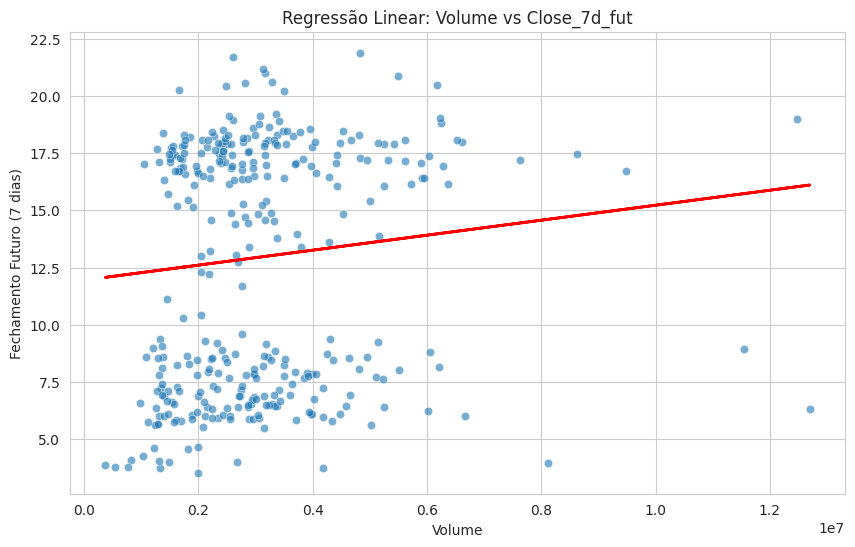

In [5]:
# Selecionar o atributo 'Volume' como variável independente e 'Close_7d_fut' como alvo
X_volume = df_process[['Volume']]
y_close_7d_fut = df_process['Close_7d_fut']

# Dividir os dados em treino e teste
X_train_vol_7d, X_test_vol_7d, y_train_7d, y_test_7d = train_test_split(X_volume, y_close_7d_fut, test_size=0.2, random_state=42)

model_vol_7d = LinearRegression()
model_vol_7d.fit(X_train_vol_7d, y_train_7d)
y_pred_vol_7d = model_vol_7d.predict(X_test_vol_7d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_vol_7d['Volume'], y=y_test_7d, alpha=0.6)
plt.plot(X_test_vol_7d['Volume'], y_pred_vol_7d, color='red', linewidth=2)
plt.title('Regressão Linear: Volume vs Close_7d_fut')
plt.xlabel('Volume')
plt.ylabel('Fechamento Futuro (7 dias)')
plt.grid(True)
plt.savefig('regressao_volume_close_7d_fut.png')
print("\nGráfico salvo como 'regressao_volume_close_7d_fut.png'")

print("\nMétricas do Modelo (Volume vs Close_7d_fut):")
print(f"Coeficiente: {model_vol_7d.coef_[0]:.8f}")
print(f"Intercepto: {model_vol_7d.intercept_:.4f}")
print(f"R-quadrado: {model_vol_7d.score(X_test_vol_7d, y_test_7d):.4f}")


### Treinando modelo: Volume vs Close_15d_fut



Gráfico salvo como 'regressao_volume_close_15d_fut.png'

Métricas do Modelo (Volume vs Close_15d_fut):
Coeficiente: 0.00000030
Intercepto: 12.1043
R-quadrado: 0.0066


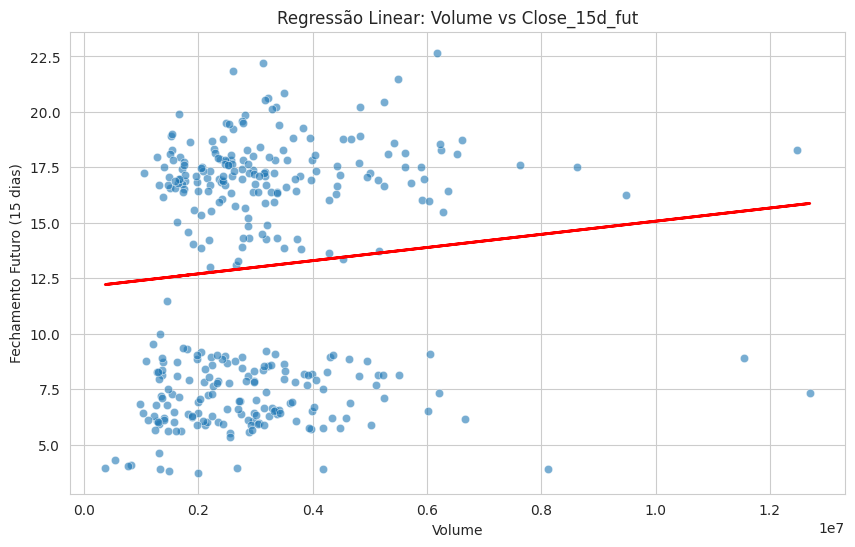

In [6]:
# Selecionar o atributo 'Volume' como variável independente e 'Close_15d_fut' como alvo
X_volume = df_process[['Volume']]
y_close_15d_fut = df_process['Close_15d_fut']

# Dividir os dados em treino e teste
X_train_vol_15d, X_test_vol_15d, y_train_15d, y_test_15d = train_test_split(X_volume, y_close_15d_fut, test_size=0.2, random_state=42)

model_vol_15d = LinearRegression()
model_vol_15d.fit(X_train_vol_15d, y_train_15d)
y_pred_vol_15d = model_vol_15d.predict(X_test_vol_15d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_vol_15d['Volume'], y=y_test_15d, alpha=0.6)
plt.plot(X_test_vol_15d['Volume'], y_pred_vol_15d, color='red', linewidth=2)
plt.title('Regressão Linear: Volume vs Close_15d_fut')
plt.xlabel('Volume')
plt.ylabel('Fechamento Futuro (15 dias)')
plt.grid(True)
plt.savefig('regressao_volume_close_15d_fut.png')
print("\nGráfico salvo como 'regressao_volume_close_15d_fut.png'")

print("\nMétricas do Modelo (Volume vs Close_15d_fut):")
print(f"Coeficiente: {model_vol_15d.coef_[0]:.8f}")
print(f"Intercepto: {model_vol_15d.intercept_:.4f}")
print(f"R-quadrado: {model_vol_15d.score(X_test_vol_15d, y_test_15d):.4f}")


### Treinando modelo: Volume vs Close_30d_fut



Gráfico salvo como 'regressao_volume_close_30d_fut.png'

Métricas do Modelo (Volume vs Close_30d_fut):
Coeficiente: 0.00000028
Intercepto: 12.2857
R-quadrado: 0.0048


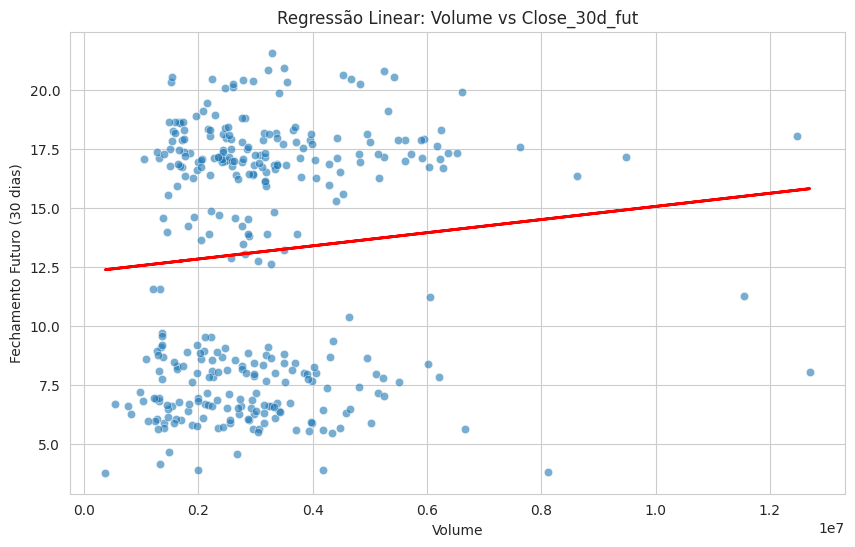

In [7]:
# Selecionar o atributo 'Volume' como variável independente e 'Close_30d_fut' como alvo
X_volume = df_process[['Volume']]
y_close_30d_fut = df_process['Close_30d_fut']

# Dividir os dados em treino e teste
X_train_vol_30d, X_test_vol_30d, y_train_30d, y_test_30d = train_test_split(X_volume, y_close_30d_fut, test_size=0.2, random_state=42)

model_vol_30d = LinearRegression()
model_vol_30d.fit(X_train_vol_30d, y_train_30d)
y_pred_vol_30d = model_vol_30d.predict(X_test_vol_30d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_vol_30d['Volume'], y=y_test_30d, alpha=0.6)
plt.plot(X_test_vol_30d['Volume'], y_pred_vol_30d, color='red', linewidth=2)
plt.title('Regressão Linear: Volume vs Close_30d_fut')
plt.xlabel('Volume')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.grid(True)
plt.savefig('regressao_volume_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_volume_close_30d_fut.png'")

print("\nMétricas do Modelo (Volume vs Close_30d_fut):")
print(f"Coeficiente: {model_vol_30d.coef_[0]:.8f}")
print(f"Intercepto: {model_vol_30d.intercept_:.4f}")
print(f"R-quadrado: {model_vol_30d.score(X_test_vol_30d, y_test_30d):.4f}")


### Treinando modelo: Open x Close 1 day future


Gráfico salvo como 'regressao_open_close_1d_fut.png'

Métricas do Modelo (Open vs Close_1d_fut):
Coeficiente: 0.99637784
Intercepto: 0.0471
R-quadrado: 0.9941


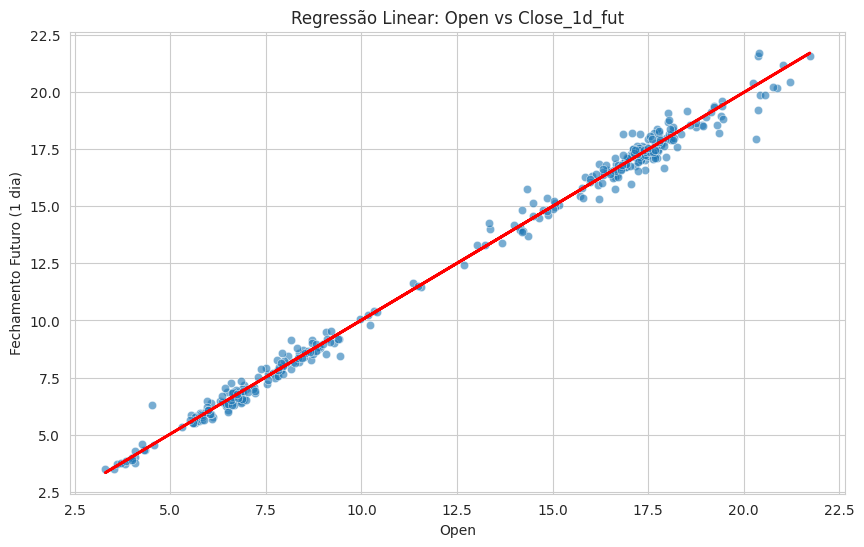

In [8]:
# Selecionar o atributo 'Open' como variável independente e 'Close_1d_fut' como alvo
X_open = df_process[['Open']]
y_close_1d_fut = df_process['Close_1d_fut']

# Dividir os dados em treino e teste
X_train_open_1d, X_test_open_1d, y_train_1d, y_test_1d = train_test_split(X_open, y_close_1d_fut, test_size=0.2, random_state=42)

model_open_1d = LinearRegression()
model_open_1d.fit(X_train_open_1d, y_train_1d)
y_pred_open_1d = model_open_1d.predict(X_test_open_1d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_open_1d['Open'], y=y_test_1d, alpha=0.6)
plt.plot(X_test_open_1d['Open'], y_pred_open_1d, color='red', linewidth=2)
plt.title('Regressão Linear: Open vs Close_1d_fut')
plt.xlabel('Open')
plt.ylabel('Fechamento Futuro (1 dia)')
plt.grid(True)
plt.savefig('regressao_open_close_1d_fut.png')
print("\nGráfico salvo como 'regressao_open_close_1d_fut.png'")

print("\nMétricas do Modelo (Open vs Close_1d_fut):")
print(f"Coeficiente: {model_open_1d.coef_[0]:.8f}")
print(f"Intercepto: {model_open_1d.intercept_:.4f}")
print(f"R-quadrado: {model_open_1d.score(X_test_open_1d, y_test_1d):.4f}")


### Treinando modelo: Open vs Close 3 days future



Gráfico salvo como 'regressao_open_close_3d_fut.png'

Métricas do Modelo (Open vs Close_3d_fut):
Coeficiente: 0.99143903
Intercepto: 0.1276
R-quadrado: 0.9877


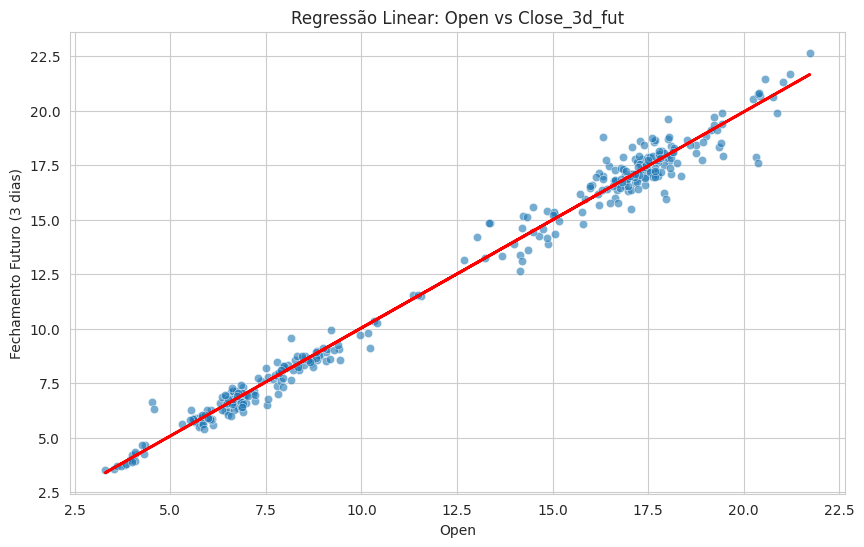

In [25]:
# Selecionar o atributo 'Open' como variável independente e 'Close_3d_fut' como alvo
X_open = df_process[['Open']]
y_close_3d_fut = df_process['Close_3d_fut']

# Dividir os dados em treino e teste
X_train_open_3d, X_test_open_3d, y_train_3d, y_test_3d = train_test_split(X_open, y_close_3d_fut, test_size=0.2, random_state=42)

model_open_3d = LinearRegression()
model_open_3d.fit(X_train_open_3d, y_train_3d)
y_pred_open_3d = model_open_3d.predict(X_test_open_3d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_open_3d['Open'], y=y_test_3d, alpha=0.6)
plt.plot(X_test_open_3d['Open'], y_pred_open_3d, color='red', linewidth=2)
plt.title('Regressão Linear: Open vs Close_3d_fut')
plt.xlabel('Open')
plt.ylabel('Fechamento Futuro (3 dias)')
plt.grid(True)
plt.savefig('regressao_open_close_3d_fut.png')
print("\nGráfico salvo como 'regressao_open_close_3d_fut.png'")

print("\nMétricas do Modelo (Open vs Close_3d_fut):")
print(f"Coeficiente: {model_open_3d.coef_[0]:.8f}")
print(f"Intercepto: {model_open_3d.intercept_:.4f}")
print(f"R-quadrado: {model_open_3d.score(X_test_open_3d, y_test_3d):.4f}")


### Treinando modelo: Open vs Close 7 days future



Gráfico salvo como 'regressao_open_close_7d_fut.png'

Métricas do Modelo (Open vs Close_7d_fut):
Coeficiente: 0.98201090
Intercepto: 0.2724
R-quadrado: 0.9767


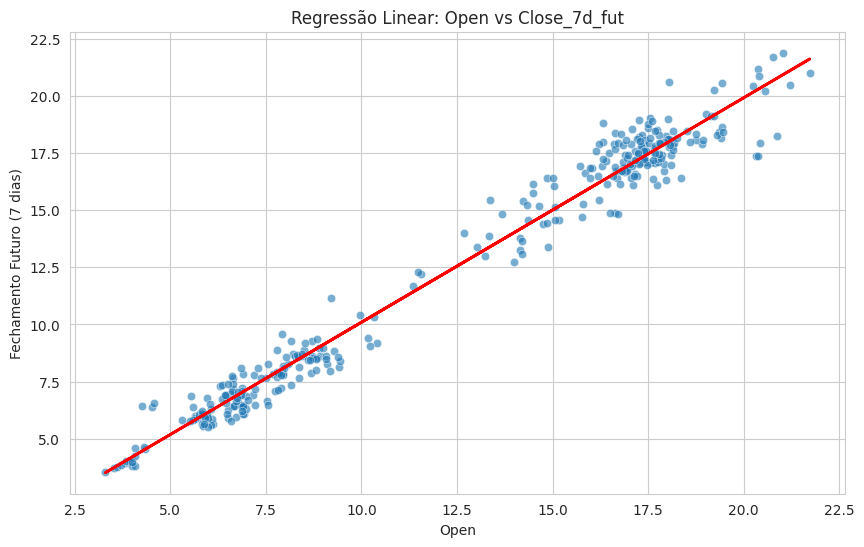

In [26]:
# Selecionar o atributo 'Open' como variável independente e 'Close_7d_fut' como alvo
X_open = df_process[['Open']]
y_close_7d_fut = df_process['Close_7d_fut']

# Dividir os dados em treino e teste
X_train_open_7d, X_test_open_7d, y_train_7d, y_test_7d = train_test_split(X_open, y_close_7d_fut, test_size=0.2, random_state=42)

model_open_7d = LinearRegression()
model_open_7d.fit(X_train_open_7d, y_train_7d)
y_pred_open_7d = model_open_7d.predict(X_test_open_7d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_open_7d['Open'], y=y_test_7d, alpha=0.6)
plt.plot(X_test_open_7d['Open'], y_pred_open_7d, color='red', linewidth=2)
plt.title('Regressão Linear: Open vs Close_7d_fut')
plt.xlabel('Open')
plt.ylabel('Fechamento Futuro (7 dias)')
plt.grid(True)
plt.savefig('regressao_open_close_7d_fut.png')
print("\nGráfico salvo como 'regressao_open_close_7d_fut.png'")

print("\nMétricas do Modelo (Open vs Close_7d_fut):")
print(f"Coeficiente: {model_open_7d.coef_[0]:.8f}")
print(f"Intercepto: {model_open_7d.intercept_:.4f}")
print(f"R-quadrado: {model_open_7d.score(X_test_open_7d, y_test_7d):.4f}")


### Treinando modelo: Open vs Close 15 days future



Gráfico salvo como 'regressao_open_close_15d_fut.png'

Métricas do Modelo (Open vs Close_15d_fut):
Coeficiente: 0.96538414
Intercepto: 0.5499
R-quadrado: 0.9602


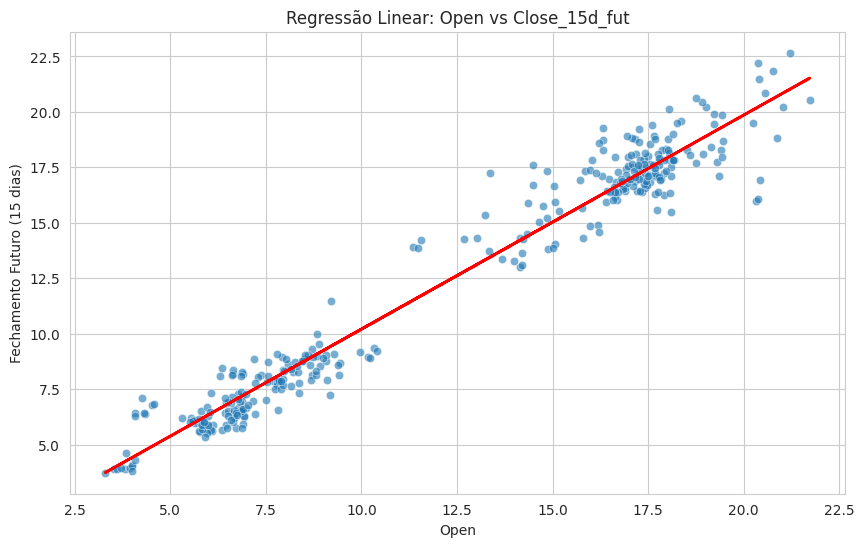

In [27]:
# Selecionar o atributo 'Open' como variável independente e 'Close_15d_fut' como alvo
X_open = df_process[['Open']]
y_close_15d_fut = df_process['Close_15d_fut']

# Dividir os dados em treino e teste
X_train_open_15d, X_test_open_15d, y_train_15d, y_test_15d = train_test_split(X_open, y_close_15d_fut, test_size=0.2, random_state=42)

model_open_15d = LinearRegression()
model_open_15d.fit(X_train_open_15d, y_train_15d)
y_pred_open_15d = model_open_15d.predict(X_test_open_15d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_open_15d['Open'], y=y_test_15d, alpha=0.6)
plt.plot(X_test_open_15d['Open'], y_pred_open_15d, color='red', linewidth=2)
plt.title('Regressão Linear: Open vs Close_15d_fut')
plt.xlabel('Open')
plt.ylabel('Fechamento Futuro (15 dias)')
plt.grid(True)
plt.savefig('regressao_open_close_15d_fut.png')
print("\nGráfico salvo como 'regressao_open_close_15d_fut.png'")

print("\nMétricas do Modelo (Open vs Close_15d_fut):")
print(f"Coeficiente: {model_open_15d.coef_[0]:.8f}")
print(f"Intercepto: {model_open_15d.intercept_:.4f}")
print(f"R-quadrado: {model_open_15d.score(X_test_open_15d, y_test_15d):.4f}")


### Treinando modelo: Open vs Close 30 days future


Gráfico salvo como 'regressao_open_close_30d_fut.png'

Métricas do Modelo (Open vs Close_30d_fut):
Coeficiente: 0.93481076
Intercepto: 1.0691
R-quadrado: 0.9126
MAE (Mean Absolute Error): 1.2097


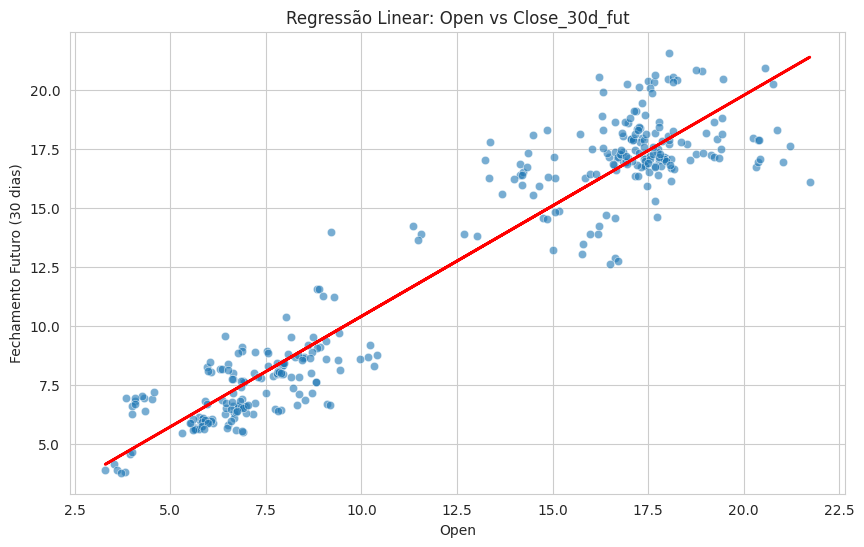

In [9]:
# Selecionar o atributo 'Open' como variável independente e 'Close_30d_fut' como alvo
X_open = df_process[['Open']]
y_close_30d_fut = df_process['Close_30d_fut']

# Dividir os dados em treino e teste
X_train_open_30d, X_test_open_30d, y_train_30d, y_test_30d = train_test_split(X_open, y_close_30d_fut, test_size=0.2, random_state=42)

model_open_30d = LinearRegression()
model_open_30d.fit(X_train_open_30d, y_train_30d)
y_pred_open_30d = model_open_30d.predict(X_test_open_30d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_open_30d['Open'], y=y_test_30d, alpha=0.6)
plt.plot(X_test_open_30d['Open'], y_pred_open_30d, color='red', linewidth=2)
plt.title('Regressão Linear: Open vs Close_30d_fut')
plt.xlabel('Open')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.grid(True)
plt.savefig('regressao_open_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_open_close_30d_fut.png'")

print("\nMétricas do Modelo (Open vs Close_30d_fut):")
print(f"Coeficiente: {model_open_30d.coef_[0]:.8f}")
print(f"Intercepto: {model_open_30d.intercept_:.4f}")
print(f"R-quadrado: {model_open_30d.score(X_test_open_30d, y_test_30d):.4f}")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test_30d, y_pred_open_30d):.4f}")

### Treinando modelo: High vs Close 1 day future


Gráfico salvo como 'regressao_high_close_1d_fut.png'

Métricas do Modelo (High vs Close_1d_fut):
Coeficiente: 0.98509991
Intercepto: -0.0187
R-quadrado: 0.9955


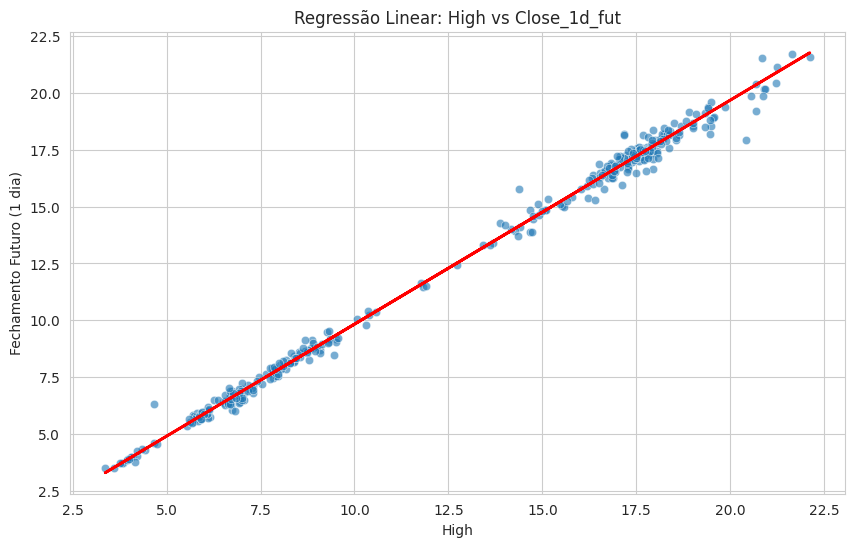

In [29]:
# Selecionar o atributo 'High' como variável independente e 'Close_1d_fut' como alvo
X_high = df_process[['High']]
y_close_1d_fut = df_process['Close_1d_fut']

# Dividir os dados em treino e teste
X_train_high_1d, X_test_high_1d, y_train_1d, y_test_1d = train_test_split(X_high, y_close_1d_fut, test_size=0.2, random_state=42)

model_high_1d = LinearRegression()
model_high_1d.fit(X_train_high_1d, y_train_1d)
y_pred_high_1d = model_high_1d.predict(X_test_high_1d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_high_1d['High'], y=y_test_1d, alpha=0.6)
plt.plot(X_test_high_1d['High'], y_pred_high_1d, color='red', linewidth=2)
plt.title('Regressão Linear: High vs Close_1d_fut')
plt.xlabel('High')
plt.ylabel('Fechamento Futuro (1 dia)')
plt.grid(True)
plt.savefig('regressao_high_close_1d_fut.png')
print("\nGráfico salvo como 'regressao_high_close_1d_fut.png'")

print("\nMétricas do Modelo (High vs Close_1d_fut):")
print(f"Coeficiente: {model_high_1d.coef_[0]:.8f}")
print(f"Intercepto: {model_high_1d.intercept_:.4f}")
print(f"R-quadrado: {model_high_1d.score(X_test_high_1d, y_test_1d):.4f}")


### Treinando modelo: High vs Close 3 days future


Gráfico salvo como 'regressao_high_close_3d_fut.png'

Métricas do Modelo (High vs Close_3d_fut):
Coeficiente: 0.98021068
Intercepto: 0.0623
R-quadrado: 0.9898


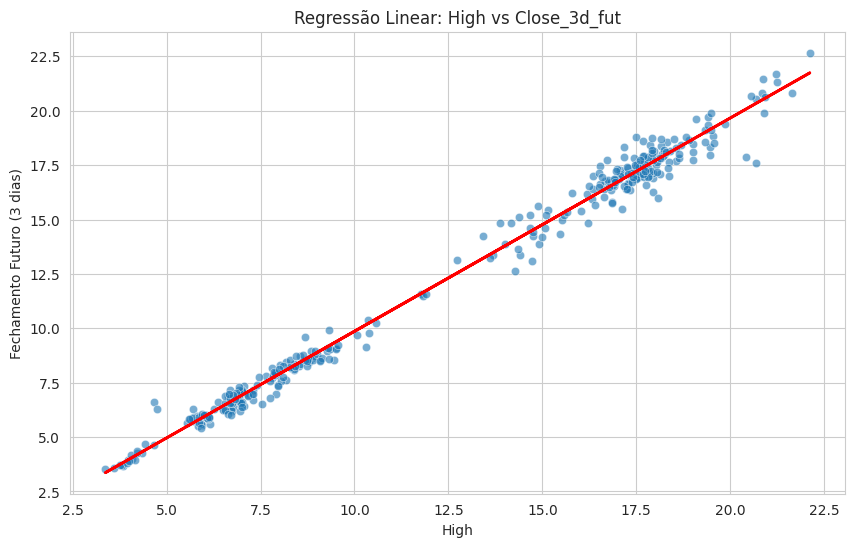

In [30]:
# Selecionar o atributo 'High' como variável independente e 'Close_3d_fut' como alvo
X_high = df_process[['High']]
y_close_3d_fut = df_process['Close_3d_fut']

# Dividir os dados em treino e teste
X_train_high_3d, X_test_high_3d, y_train_3d, y_test_3d = train_test_split(X_high, y_close_3d_fut, test_size=0.2, random_state=42)

model_high_3d = LinearRegression()
model_high_3d.fit(X_train_high_3d, y_train_3d)
y_pred_high_3d = model_high_3d.predict(X_test_high_3d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_high_3d['High'], y=y_test_3d, alpha=0.6)
plt.plot(X_test_high_3d['High'], y_pred_high_3d, color='red', linewidth=2)
plt.title('Regressão Linear: High vs Close_3d_fut')
plt.xlabel('High')
plt.ylabel('Fechamento Futuro (3 dias)')
plt.grid(True)
plt.savefig('regressao_high_close_3d_fut.png')
print("\nGráfico salvo como 'regressao_high_close_3d_fut.png'")

print("\nMétricas do Modelo (High vs Close_3d_fut):")
print(f"Coeficiente: {model_high_3d.coef_[0]:.8f}")
print(f"Intercepto: {model_high_3d.intercept_:.4f}")
print(f"R-quadrado: {model_high_3d.score(X_test_high_3d, y_test_3d):.4f}")


### Treinando modelo: High vs Close 7 days future


Gráfico salvo como 'regressao_high_close_7d_fut.png'

Métricas do Modelo (High vs Close_7d_fut):
Coeficiente: 0.97073997
Intercepto: 0.2097
R-quadrado: 0.9790


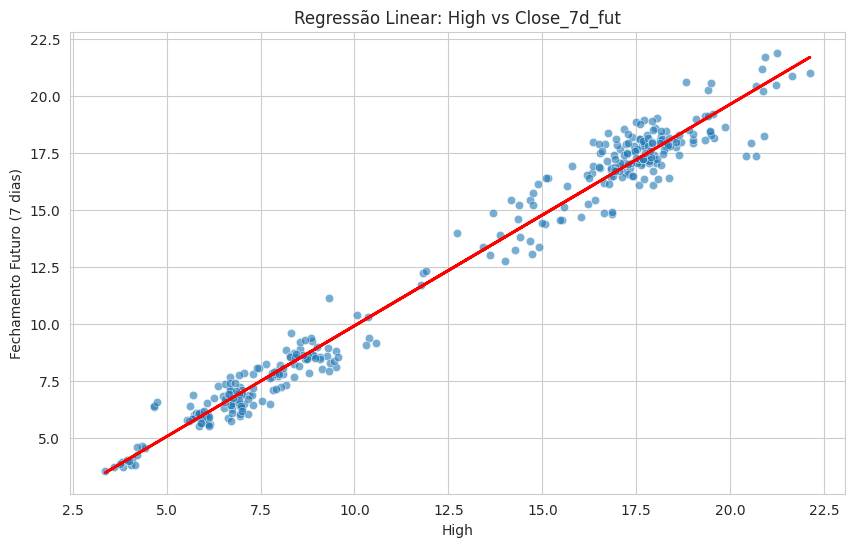

In [31]:
# Selecionar o atributo 'High' como variável independente e 'Close_7d_fut' como alvo
X_high = df_process[['High']]
y_close_7d_fut = df_process['Close_7d_fut']

# Dividir os dados em treino e teste
X_train_high_7d, X_test_high_7d, y_train_7d, y_test_7d = train_test_split(X_high, y_close_7d_fut, test_size=0.2, random_state=42)

model_high_7d = LinearRegression()
model_high_7d.fit(X_train_high_7d, y_train_7d)
y_pred_high_7d = model_high_7d.predict(X_test_high_7d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_high_7d['High'], y=y_test_7d, alpha=0.6)
plt.plot(X_test_high_7d['High'], y_pred_high_7d, color='red', linewidth=2)
plt.title('Regressão Linear: High vs Close_7d_fut')
plt.xlabel('High')
plt.ylabel('Fechamento Futuro (7 dias)')
plt.grid(True)
plt.savefig('regressao_high_close_7d_fut.png')
print("\nGráfico salvo como 'regressao_high_close_7d_fut.png'")

print("\nMétricas do Modelo (High vs Close_7d_fut):")
print(f"Coeficiente: {model_high_7d.coef_[0]:.8f}")
print(f"Intercepto: {model_high_7d.intercept_:.4f}")
print(f"R-quadrado: {model_high_7d.score(X_test_high_7d, y_test_7d):.4f}")


### Treinando modelo: High vs Close 15 days future


Gráfico salvo como 'regressao_high_close_15d_fut.png'

Métricas do Modelo (High vs Close_15d_fut):
Coeficiente: 0.95423403
Intercepto: 0.4892
R-quadrado: 0.9633


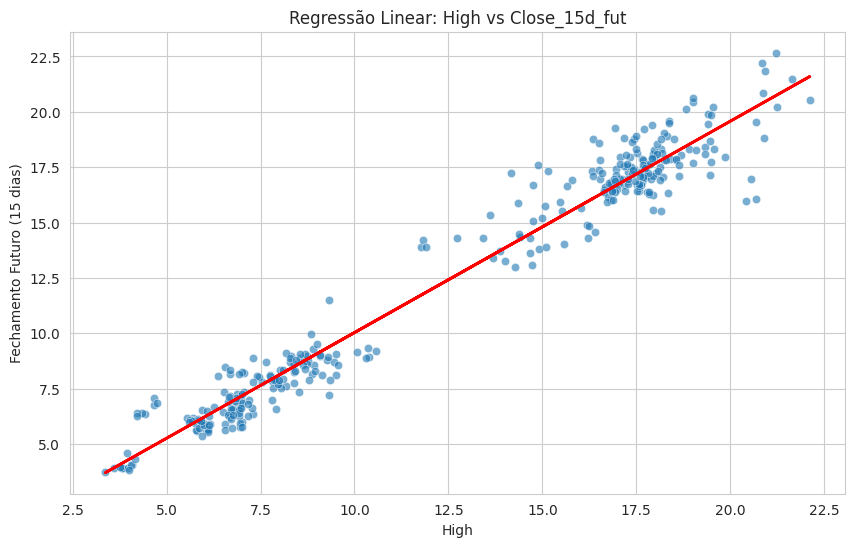

In [32]:
# Selecionar o atributo 'High' como variável independente e 'Close_15d_fut' como alvo
X_high = df_process[['High']]
y_close_15d_fut = df_process['Close_15d_fut']

# Dividir os dados em treino e teste
X_train_high_15d, X_test_high_15d, y_train_15d, y_test_15d = train_test_split(X_high, y_close_15d_fut, test_size=0.2, random_state=42)

model_high_15d = LinearRegression()
model_high_15d.fit(X_train_high_15d, y_train_15d)
y_pred_high_15d = model_high_15d.predict(X_test_high_15d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_high_15d['High'], y=y_test_15d, alpha=0.6)
plt.plot(X_test_high_15d['High'], y_pred_high_15d, color='red', linewidth=2)
plt.title('Regressão Linear: High vs Close_15d_fut')
plt.xlabel('High')
plt.ylabel('Fechamento Futuro (15 dias)')
plt.grid(True)
plt.savefig('regressao_high_close_15d_fut.png')
print("\nGráfico salvo como 'regressao_high_close_15d_fut.png'")

print("\nMétricas do Modelo (High vs Close_15d_fut):")
print(f"Coeficiente: {model_high_15d.coef_[0]:.8f}")
print(f"Intercepto: {model_high_15d.intercept_:.4f}")
print(f"R-quadrado: {model_high_15d.score(X_test_high_15d, y_test_15d):.4f}")


### Treinando modelo: High vs Close 30 days future


Gráfico salvo como 'regressao_high_close_30d_fut.png'

Métricas do Modelo (High vs Close_30d_fut):
Coeficiente: 0.92381130
Intercepto: 1.0129
R-quadrado: 0.9157
MAE (Mean Absolute Error): 1.1791


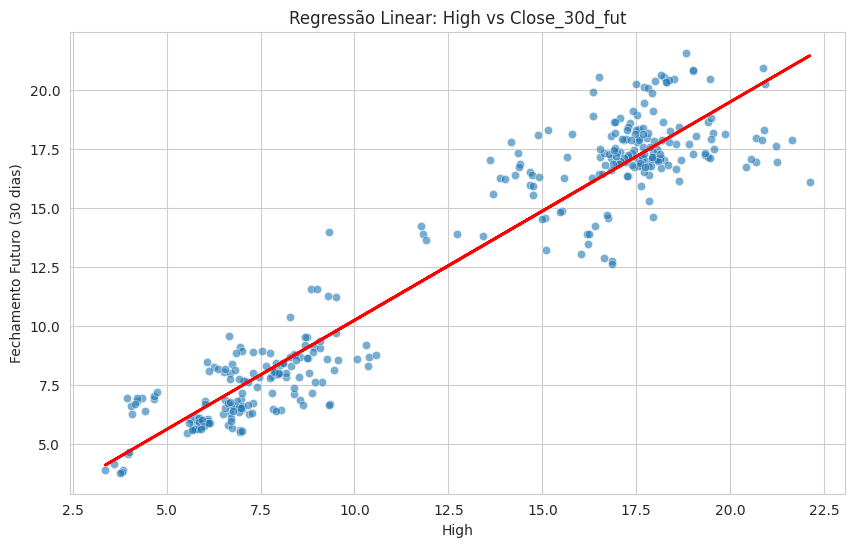

In [10]:
# Selecionar o atributo 'High' como variável independente e 'Close_30d_fut' como alvo
X_high = df_process[['High']]
y_close_30d_fut = df_process['Close_30d_fut']

# Dividir os dados em treino e teste
X_train_high_30d, X_test_high_30d, y_train_30d, y_test_30d = train_test_split(X_high, y_close_30d_fut, test_size=0.2, random_state=42)

model_high_30d = LinearRegression()
model_high_30d.fit(X_train_high_30d, y_train_30d)
y_pred_high_30d = model_high_30d.predict(X_test_high_30d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_high_30d['High'], y=y_test_30d, alpha=0.6)
plt.plot(X_test_high_30d['High'], y_pred_high_30d, color='red', linewidth=2)
plt.title('Regressão Linear: High vs Close_30d_fut')
plt.xlabel('High')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.grid(True)
plt.savefig('regressao_high_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_high_close_30d_fut.png'")

print("\nMétricas do Modelo (High vs Close_30d_fut):")
print(f"Coeficiente: {model_high_30d.coef_[0]:.8f}")
print(f"Intercepto: {model_high_30d.intercept_:.4f}")
print(f"R-quadrado: {model_high_30d.score(X_test_high_30d, y_test_30d):.4f}")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test_30d, y_pred_high_30d):.4f}")

### Treinando modelo: Low vs Close 1 day future


Gráfico salvo como 'regressao_low_close_1d_fut.png'

Métricas do Modelo (Low vs Close_1d_fut):
Coeficiente: 1.00981050
Intercepto: 0.0888
R-quadrado: 0.9958


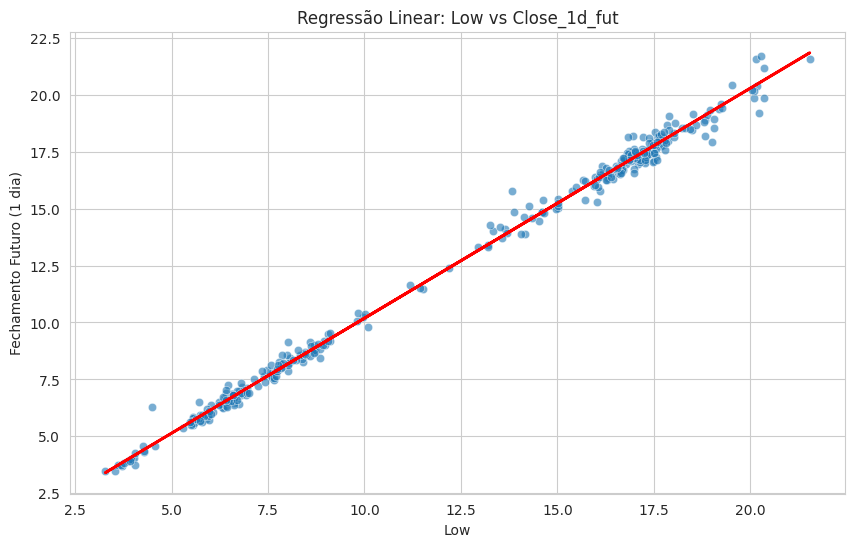

In [34]:
# Selecionar o atributo 'Low' como variável independente e 'Close_1d_fut' como alvo
X_low = df_process[['Low']]
y_close_1d_fut = df_process['Close_1d_fut']

# Dividir os dados em treino e teste
X_train_low_1d, X_test_low_1d, y_train_1d, y_test_1d = train_test_split(X_low, y_close_1d_fut, test_size=0.2, random_state=42)

model_low_1d = LinearRegression()
model_low_1d.fit(X_train_low_1d, y_train_1d)
y_pred_low_1d = model_low_1d.predict(X_test_low_1d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_low_1d['Low'], y=y_test_1d, alpha=0.6)
plt.plot(X_test_low_1d['Low'], y_pred_low_1d, color='red', linewidth=2)
plt.title('Regressão Linear: Low vs Close_1d_fut')
plt.xlabel('Low')
plt.ylabel('Fechamento Futuro (1 dia)')
plt.grid(True)
plt.savefig('regressao_low_close_1d_fut.png')
print("\nGráfico salvo como 'regressao_low_close_1d_fut.png'")

print("\nMétricas do Modelo (Low vs Close_1d_fut):")
print(f"Coeficiente: {model_low_1d.coef_[0]:.8f}")
print(f"Intercepto: {model_low_1d.intercept_:.4f}")
print(f"R-quadrado: {model_low_1d.score(X_test_low_1d, y_test_1d):.4f}")


### Treinando modelo: Low vs Close 3 days future


Gráfico salvo como 'regressao_low_close_3d_fut.png'

Métricas do Modelo (Low vs Close_3d_fut):
Coeficiente: 1.00479163
Intercepto: 0.1693
R-quadrado: 0.9895


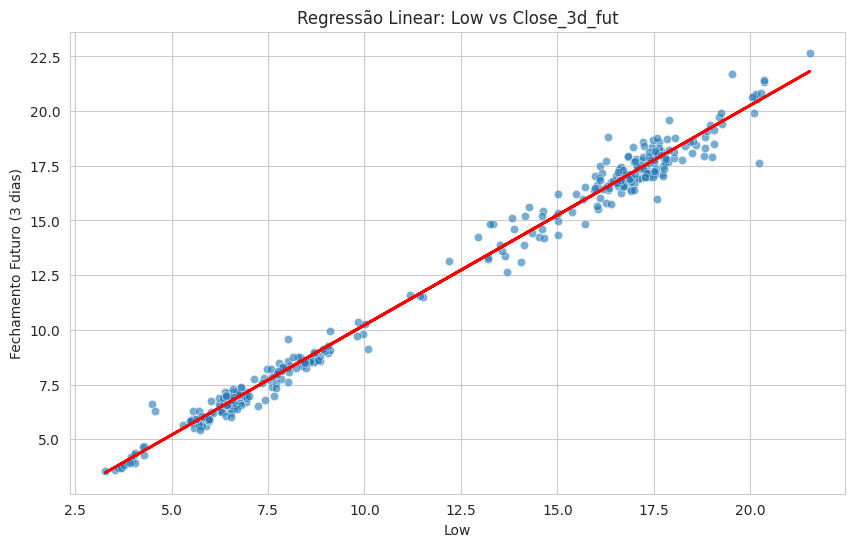

In [35]:
# Selecionar o atributo 'Low' como variável independente e 'Close_3d_fut' como alvo
X_low = df_process[['Low']]
y_close_3d_fut = df_process['Close_3d_fut']

# Dividir os dados em treino e teste
X_train_low_3d, X_test_low_3d, y_train_3d, y_test_3d = train_test_split(X_low, y_close_3d_fut, test_size=0.2, random_state=42)

model_low_3d = LinearRegression()
model_low_3d.fit(X_train_low_3d, y_train_3d)
y_pred_low_3d = model_low_3d.predict(X_test_low_3d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_low_3d['Low'], y=y_test_3d, alpha=0.6)
plt.plot(X_test_low_3d['Low'], y_pred_low_3d, color='red', linewidth=2)
plt.title('Regressão Linear: Low vs Close_3d_fut')
plt.xlabel('Low')
plt.ylabel('Fechamento Futuro (3 dias)')
plt.grid(True)
plt.savefig('regressao_low_close_3d_fut.png')
print("\nGráfico salvo como 'regressao_low_close_3d_fut.png'")

print("\nMétricas do Modelo (Low vs Close_3d_fut):")
print(f"Coeficiente: {model_low_3d.coef_[0]:.8f}")
print(f"Intercepto: {model_low_3d.intercept_:.4f}")
print(f"R-quadrado: {model_low_3d.score(X_test_low_3d, y_test_3d):.4f}")


### Treinando modelo: Low vs Close 7 days future


Gráfico salvo como 'regressao_low_close_7d_fut.png'

Métricas do Modelo (Low vs Close_7d_fut):
Coeficiente: 0.99507931
Intercepto: 0.3157
R-quadrado: 0.9790


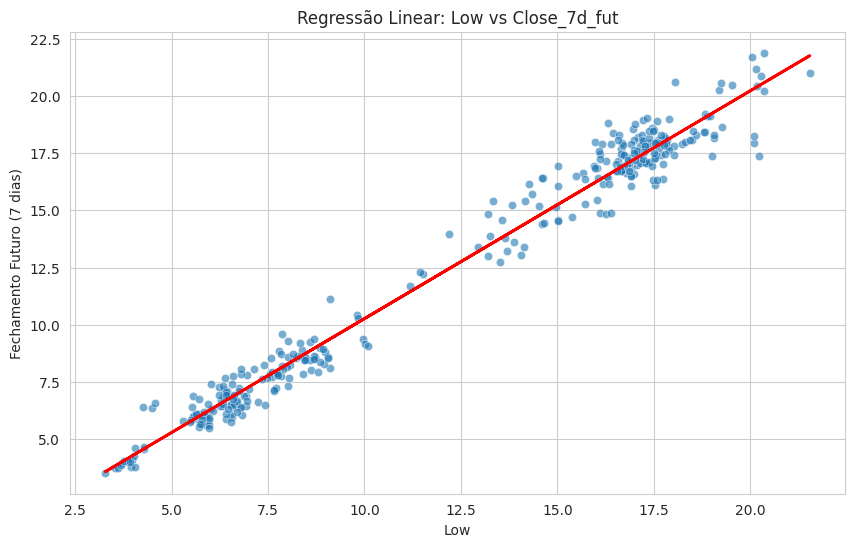

In [36]:
# Selecionar o atributo 'Low' como variável independente e 'Close_7d_fut' como alvo
X_low = df_process[['Low']]
y_close_7d_fut = df_process['Close_7d_fut']

# Dividir os dados em treino e teste
X_train_low_7d, X_test_low_7d, y_train_7d, y_test_7d = train_test_split(X_low, y_close_7d_fut, test_size=0.2, random_state=42)

model_low_7d = LinearRegression()
model_low_7d.fit(X_train_low_7d, y_train_7d)
y_pred_low_7d = model_low_7d.predict(X_test_low_7d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_low_7d['Low'], y=y_test_7d, alpha=0.6)
plt.plot(X_test_low_7d['Low'], y_pred_low_7d, color='red', linewidth=2)
plt.title('Regressão Linear: Low vs Close_7d_fut')
plt.xlabel('Low')
plt.ylabel('Fechamento Futuro (7 dias)')
plt.grid(True)
plt.savefig('regressao_low_close_7d_fut.png')
print("\nGráfico salvo como 'regressao_low_close_7d_fut.png'")

print("\nMétricas do Modelo (Low vs Close_7d_fut):")
print(f"Coeficiente: {model_low_7d.coef_[0]:.8f}")
print(f"Intercepto: {model_low_7d.intercept_:.4f}")
print(f"R-quadrado: {model_low_7d.score(X_test_low_7d, y_test_7d):.4f}")


### Treinando modelo: Low vs Close 15 days future


Gráfico salvo como 'regressao_low_close_15d_fut.png'

Métricas do Modelo (Low vs Close_15d_fut):
Coeficiente: 0.97825698
Intercepto: 0.5922
R-quadrado: 0.9625


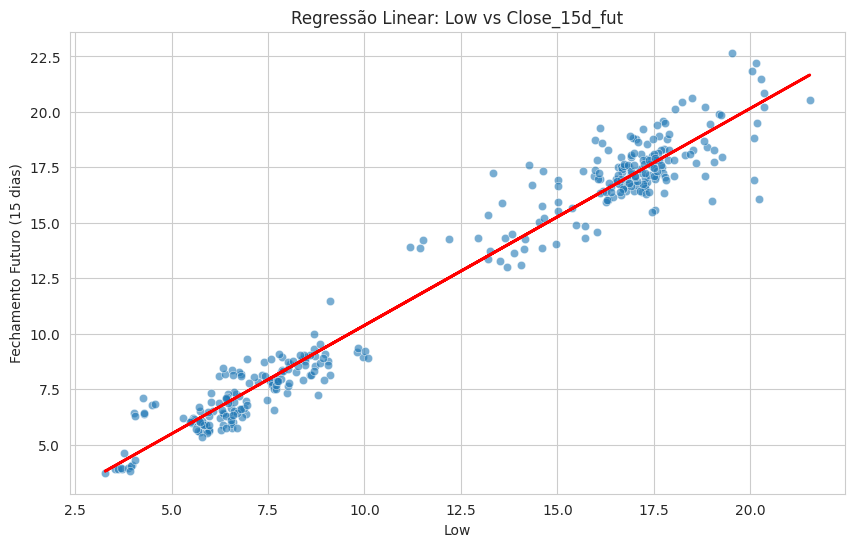

In [37]:
# Selecionar o atributo 'Low' como variável independente e 'Close_15d_fut' como alvo
X_low = df_process[['Low']]
y_close_15d_fut = df_process['Close_15d_fut']

# Dividir os dados em treino e teste
X_train_low_15d, X_test_low_15d, y_train_15d, y_test_15d = train_test_split(X_low, y_close_15d_fut, test_size=0.2, random_state=42)

model_low_15d = LinearRegression()
model_low_15d.fit(X_train_low_15d, y_train_15d)
y_pred_low_15d = model_low_15d.predict(X_test_low_15d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_low_15d['Low'], y=y_test_15d, alpha=0.6)
plt.plot(X_test_low_15d['Low'], y_pred_low_15d, color='red', linewidth=2)
plt.title('Regressão Linear: Low vs Close_15d_fut')
plt.xlabel('Low')
plt.ylabel('Fechamento Futuro (15 dias)')
plt.grid(True)
plt.savefig('regressao_low_close_15d_fut.png')
print("\nGráfico salvo como 'regressao_low_close_15d_fut.png'")

print("\nMétricas do Modelo (Low vs Close_15d_fut):")
print(f"Coeficiente: {model_low_15d.coef_[0]:.8f}")
print(f"Intercepto: {model_low_15d.intercept_:.4f}")
print(f"R-quadrado: {model_low_15d.score(X_test_low_15d, y_test_15d):.4f}")


### Treinando modelo: Low vs Close 30 days future


Gráfico salvo como 'regressao_low_close_30d_fut.png'

Métricas do Modelo (Low vs Close_30d_fut):
Coeficiente: 0.94719429
Intercepto: 1.1111
R-quadrado: 0.9154
MAE (Mean Absolute Error): 1.1930


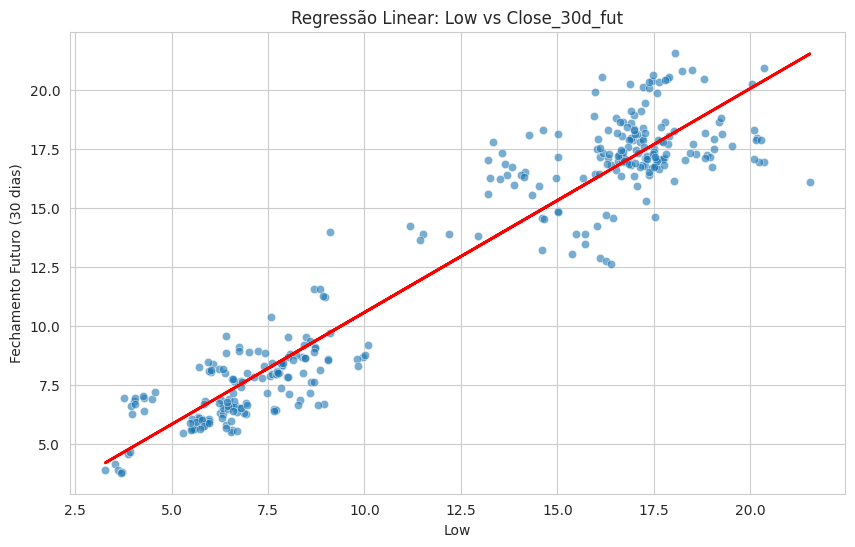

In [11]:
# Selecionar o atributo 'Low' como variável independente e 'Close_30d_fut' como alvo
X_low = df_process[['Low']]
y_close_30d_fut = df_process['Close_30d_fut']

# Dividir os dados em treino e teste
X_train_low_30d, X_test_low_30d, y_train_30d, y_test_30d = train_test_split(X_low, y_close_30d_fut, test_size=0.2, random_state=42)

model_low_30d = LinearRegression()
model_low_30d.fit(X_train_low_30d, y_train_30d)
y_pred_low_30d = model_low_30d.predict(X_test_low_30d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_low_30d['Low'], y=y_test_30d, alpha=0.6)
plt.plot(X_test_low_30d['Low'], y_pred_low_30d, color='red', linewidth=2)
plt.title('Regressão Linear: Low vs Close_30d_fut')
plt.xlabel('Low')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.grid(True)
plt.savefig('regressao_low_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_low_close_30d_fut.png'")

print("\nMétricas do Modelo (Low vs Close_30d_fut):")
print(f"Coeficiente: {model_low_30d.coef_[0]:.8f}")
print(f"Intercepto: {model_low_30d.intercept_:.4f}")
print(f"R-quadrado: {model_low_30d.score(X_test_low_30d, y_test_30d):.4f}")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test_30d, y_pred_low_30d):.4f}")

### Treinando modelo: Close vs Volume 1day future
Vamos prever o volume futuro de 1 dia usando o valor de fechamento atual como variável independente.


Gráfico salvo como 'regressao_close_volume_1d_fut.png'

Métricas do Modelo (Close vs Volume_1d_fut):
Coeficiente: 32559.02308007
Intercepto: 2597074.1051
R-quadrado: 0.0084


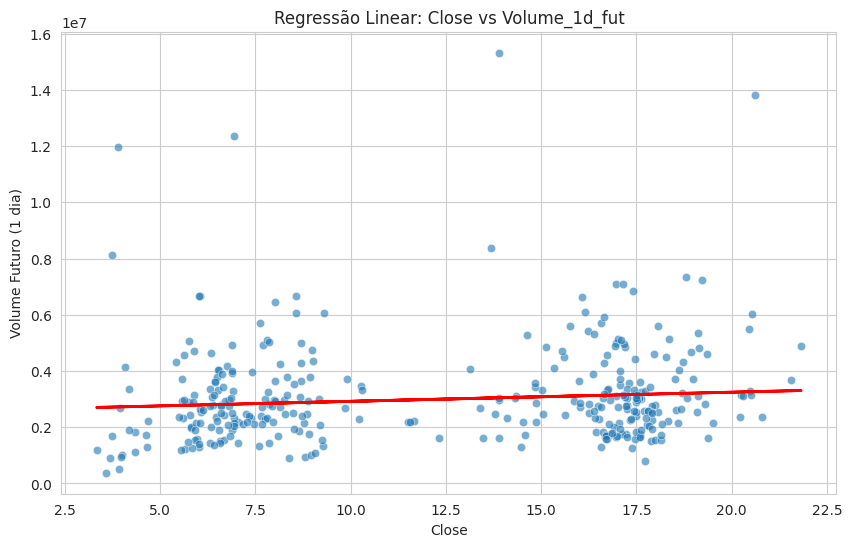

In [39]:
# Selecionar o atributo 'Close' como variável independente e 'Volume_1d_fut' como alvo
X_close = df_process[['Close']]
y_volume_1d_fut = df_process['Volume_1d_fut']

# Dividir os dados em treino e teste
X_train_close_1d, X_test_close_1d, y_train_vol_1d, y_test_vol_1d = train_test_split(X_close, y_volume_1d_fut, test_size=0.2, random_state=42)

model_close_vol_1d = LinearRegression()
model_close_vol_1d.fit(X_train_close_1d, y_train_vol_1d)
y_pred_close_vol_1d = model_close_vol_1d.predict(X_test_close_1d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_close_1d['Close'], y=y_test_vol_1d, alpha=0.6)
plt.plot(X_test_close_1d['Close'], y_pred_close_vol_1d, color='red', linewidth=2)
plt.title('Regressão Linear: Close vs Volume_1d_fut')
plt.xlabel('Close')
plt.ylabel('Volume Futuro (1 dia)')
plt.grid(True)
plt.savefig('regressao_close_volume_1d_fut.png')
print("\nGráfico salvo como 'regressao_close_volume_1d_fut.png'")

print("\nMétricas do Modelo (Close vs Volume_1d_fut):")
print(f"Coeficiente: {model_close_vol_1d.coef_[0]:.8f}")
print(f"Intercepto: {model_close_vol_1d.intercept_:.4f}")
print(f"R-quadrado: {model_close_vol_1d.score(X_test_close_1d, y_test_vol_1d):.4f}")


### Treinando modelo: Close vs Volume 3 days future
Prevendo o volume futuro de 3 dias usando o valor de fechamento atual como variável independente.


Gráfico salvo como 'regressao_close_volume_3d_fut.png'

Métricas do Modelo (Close vs Volume_3d_fut):
Coeficiente: 30306.73758294
Intercepto: 2629177.3443
R-quadrado: 0.0143


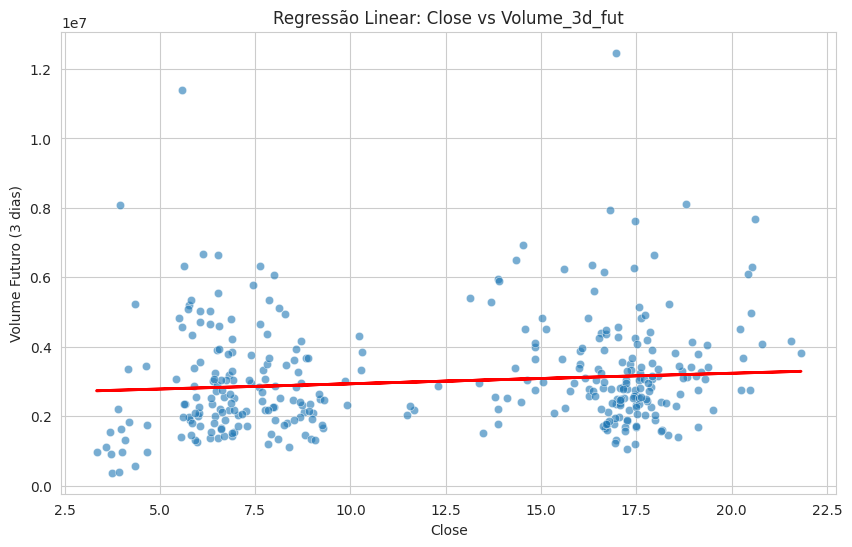

In [40]:
# Selecionar o atributo 'Close' como variável independente e 'Volume_3d_fut' como alvo
X_close = df_process[['Close']]
y_volume_3d_fut = df_process['Volume_3d_fut']

# Dividir os dados em treino e teste
X_train_close_3d, X_test_close_3d, y_train_vol_3d, y_test_vol_3d = train_test_split(X_close, y_volume_3d_fut, test_size=0.2, random_state=42)

model_close_vol_3d = LinearRegression()
model_close_vol_3d.fit(X_train_close_3d, y_train_vol_3d)
y_pred_close_vol_3d = model_close_vol_3d.predict(X_test_close_3d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_close_3d['Close'], y=y_test_vol_3d, alpha=0.6)
plt.plot(X_test_close_3d['Close'], y_pred_close_vol_3d, color='red', linewidth=2)
plt.title('Regressão Linear: Close vs Volume_3d_fut')
plt.xlabel('Close')
plt.ylabel('Volume Futuro (3 dias)')
plt.grid(True)
plt.savefig('regressao_close_volume_3d_fut.png')
print("\nGráfico salvo como 'regressao_close_volume_3d_fut.png'")

print("\nMétricas do Modelo (Close vs Volume_3d_fut):")
print(f"Coeficiente: {model_close_vol_3d.coef_[0]:.8f}")
print(f"Intercepto: {model_close_vol_3d.intercept_:.4f}")
print(f"R-quadrado: {model_close_vol_3d.score(X_test_close_3d, y_test_vol_3d):.4f}")


### Treinando modelo: Close vs Volume 7 days future
Prevendo o volume futuro de 7 dias usando o valor de fechamento atual como variável independente.


Gráfico salvo como 'regressao_close_volume_7d_fut.png'

Métricas do Modelo (Close vs Volume_7d_fut):
Coeficiente: 27295.72427341
Intercepto: 2662228.1422
R-quadrado: 0.0073


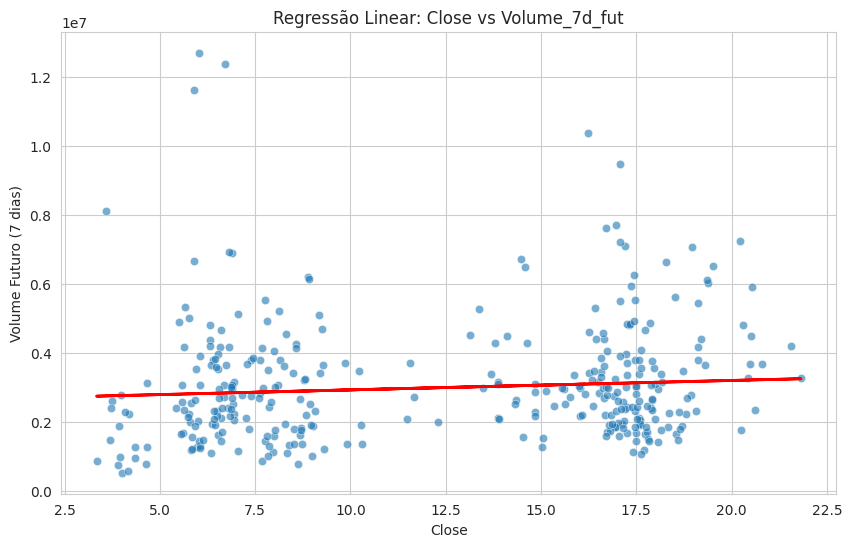

In [41]:
# Selecionar o atributo 'Close' como variável independente e 'Volume_7d_fut' como alvo
X_close = df_process[['Close']]
y_volume_7d_fut = df_process['Volume_7d_fut']

# Dividir os dados em treino e teste
X_train_close_7d, X_test_close_7d, y_train_vol_7d, y_test_vol_7d = train_test_split(X_close, y_volume_7d_fut, test_size=0.2, random_state=42)

model_close_vol_7d = LinearRegression()
model_close_vol_7d.fit(X_train_close_7d, y_train_vol_7d)
y_pred_close_vol_7d = model_close_vol_7d.predict(X_test_close_7d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_close_7d['Close'], y=y_test_vol_7d, alpha=0.6)
plt.plot(X_test_close_7d['Close'], y_pred_close_vol_7d, color='red', linewidth=2)
plt.title('Regressão Linear: Close vs Volume_7d_fut')
plt.xlabel('Close')
plt.ylabel('Volume Futuro (7 dias)')
plt.grid(True)
plt.savefig('regressao_close_volume_7d_fut.png')
print("\nGráfico salvo como 'regressao_close_volume_7d_fut.png'")

print("\nMétricas do Modelo (Close vs Volume_7d_fut):")
print(f"Coeficiente: {model_close_vol_7d.coef_[0]:.8f}")
print(f"Intercepto: {model_close_vol_7d.intercept_:.4f}")
print(f"R-quadrado: {model_close_vol_7d.score(X_test_close_7d, y_test_vol_7d):.4f}")


### Treinando modelo: Close vs Volume 30 days future
Prevendo o volume futuro de 30 dias usando o valor de fechamento atual como variável independente.


Gráfico salvo como 'regressao_close_volume_30d_fut.png'

Métricas do Modelo (Close vs Volume_30d_fut):
Coeficiente: 20929.85250778
Intercepto: 2774681.2973
R-quadrado: 0.0094


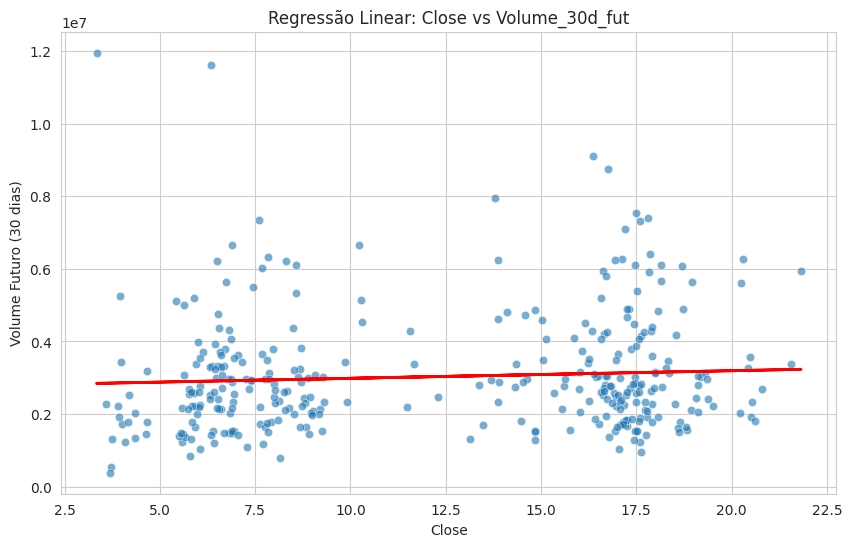

In [43]:
# Selecionar o atributo 'Close' como variável independente e 'Volume_30d_fut' como alvo
X_close = df_process[['Close']]
y_volume_30d_fut = df_process['Volume_30d_fut']

# Dividir os dados em treino e teste
X_train_close_30d, X_test_close_30d, y_train_vol_30d, y_test_vol_30d = train_test_split(X_close, y_volume_30d_fut, test_size=0.2, random_state=42)

model_close_vol_30d = LinearRegression()
model_close_vol_30d.fit(X_train_close_30d, y_train_vol_30d)
y_pred_close_vol_30d = model_close_vol_30d.predict(X_test_close_30d)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_close_30d['Close'], y=y_test_vol_30d, alpha=0.6)
plt.plot(X_test_close_30d['Close'], y_pred_close_vol_30d, color='red', linewidth=2)
plt.title('Regressão Linear: Close vs Volume_30d_fut')
plt.xlabel('Close')
plt.ylabel('Volume Futuro (30 dias)')
plt.grid(True)
plt.savefig('regressao_close_volume_30d_fut.png')
print("\nGráfico salvo como 'regressao_close_volume_30d_fut.png'")

print("\nMétricas do Modelo (Close vs Volume_30d_fut):")
print(f"Coeficiente: {model_close_vol_30d.coef_[0]:.8f}")
print(f"Intercepto: {model_close_vol_30d.intercept_:.4f}")
print(f"R-quadrado: {model_close_vol_30d.score(X_test_close_30d, y_test_vol_30d):.4f}")
